In [1]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study3.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
outputdirCleaned = os.path.join(topdir, f'data/{study}/Cleaned')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.respon

Data Processing (fix string representations of lists)

In [2]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [283]:
#for entry in df_combined['feedback']:
#   print(entry)

Sanity Checks

In [3]:
#Look at fertility score in training by participant/category in accomodate task
df = df_accommodate[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high        7.409562
1      low        3.638249


In [4]:
#Look at fertility score in training by participant/category in predict task
df = df_predict[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high        7.409562
1      low        3.638249


In [5]:
#Overall means by category in accommodate task (participant responses)
df = df_accommodate[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high           7.06682
1      low          4.400922


In [6]:
#Overall means by actual testing category in prediction task
df = df_predict[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          6.953917
1      low          4.451613


In [7]:
df_combined.groupby('irrelevant_dim')['feet_high'].value_counts() #Should be perfectly equal (or roughly equal after dropping participants)


irrelevant_dim  feet_high
color           F            108
                C            106
feet            C            110
                F            110
Name: count, dtype: int64

Timing

task
accommodate    609.249643
predict        354.447151
Name: trial_stop_time, dtype: float64


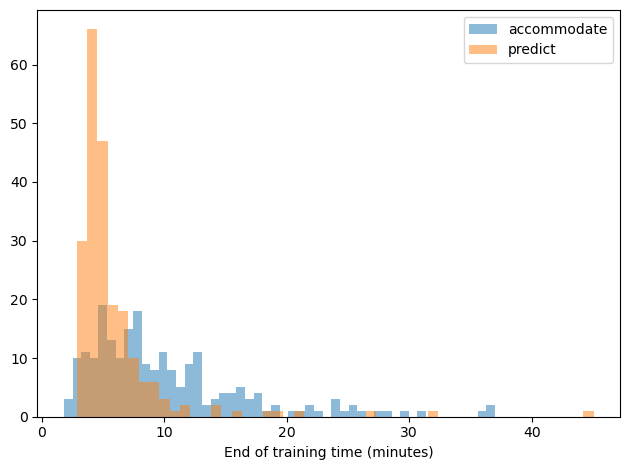

In [8]:
#Look at average time across task
df_combined['trial_stop_time'].describe()
avg_time = df_combined.groupby(['task'])['trial_stop_time'].mean()
print(avg_time)

for task, subdf in df_combined.groupby('task'):
    plt.hist(
        subdf['trial_stop_time']/60,
        bins=50,
        alpha=0.5,
        label=task
    )

plt.xlabel('End of training time (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure1TrialStopTimeByTask.png'))
plt.show()


**Primary Analysis #1**

Part 1: Model Parameter Score Complexity across conditions

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    122     95
predict        150     67
Chi-square = 7.180
df = 1
p-value = 0.0074


In [10]:
print(df_params)

     participant         task  model_param_score  conditionOrder  \
0              1  accommodate                  1             183   
1              2  accommodate                  2              75   
2              3  accommodate                  1             100   
3              4  accommodate                  1              61   
4              5  accommodate                  2              97   
..           ...          ...                ...             ...   
429          430      predict                  1              52   
430          431      predict                  1             147   
431          432      predict                  2               9   
432          433      predict                  1             204   
433          434      predict                  1             120   

    irrelevant_dim feet_high  overfit  
0            color         F    False  
1            color         F     True  
2             feet         F    False  
3            color     

In [11]:
import pandas as pd

#Look at average ratings by model_param_score in predict task, by category

# Keep only predict participantss from df_params, with model_param_score
predict_params = df_params.loc[
    df_params['task'] == 'predict',
    ['conditionOrder', 'model_param_score']
].copy()

# Keep rating data
df_pred = df_predict[['conditionOrder', 'testing_categories', 'testing_responses']].copy()

# Explode testing categories/responses into long 
df_pred_long = (
    df_pred
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category',
                     'testing_responses': 'rating'})
)

# Merge model_param_score onto the prediction ratings using conditionOrder
df_merged = df_pred_long.merge(
    predict_params,
    on='conditionOrder',
    how='inner'
)

# Make rating numeric
df_merged['rating'] = pd.to_numeric(df_merged['rating'], errors='coerce')

# Keep only model_param_score 0, 1, 2
df_merged = df_merged[df_merged['model_param_score'].isin([0, 1, 2])]

# Average ratings by model_param_score and category
avg_rating = (
    df_merged
    .groupby(['model_param_score', 'category'], as_index=False)['rating']
    .mean()
    .sort_values(['model_param_score', 'category'])
)

print(avg_rating)

   model_param_score category    rating
0                  0     high  6.121951
1                  0      low  5.731707
2                  1     high  7.151376
3                  1      low  4.192661
4                  2     high  7.141791
5                  2      low  4.089552


          task irrelevant_dim      mean  sum  count  overfit_percent
0  accommodate          color  0.411215   44    107        41.121495
1  accommodate           feet  0.463636   51    110        46.363636
2      predict          color  0.280374   30    107        28.037383
3      predict           feet  0.336364   37    110        33.636364


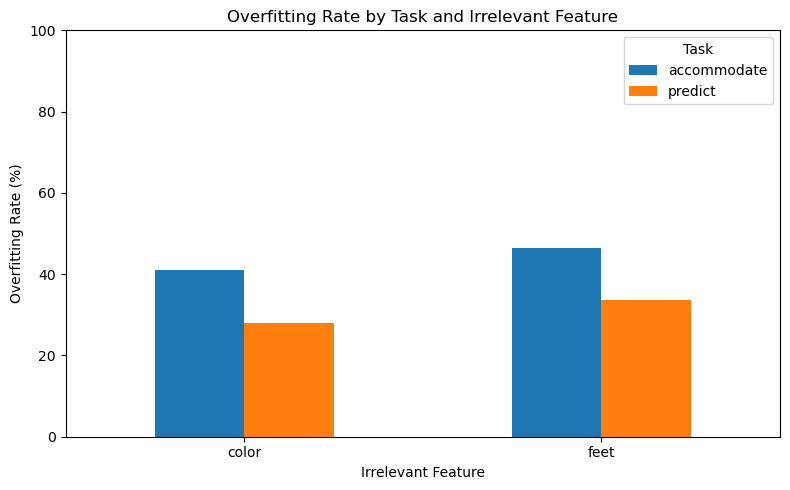

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Overfitting rate by task and irrelevant feature
overfit_summary = (
    df_params
    .groupby(['task', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

# Convert mean proportion to percent
overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

#Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Pivot for plot
plot_data = overfit_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure2OverfittingRateByTask.png'))
plt.show()

In [25]:
#Filter out participants with small differences between high and low fertility categories

df = df_combined[['task', 'conditionOrder', 'testing_categories', 'testing_responses']].copy()

df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category',
                     'testing_responses': 'rating'})
)

# make sure ratings are numeric
df_long['rating'] = pd.to_numeric(df_long['rating'], errors='coerce')

participant_means = (
    df_long
    .groupby(['task', 'conditionOrder', 'category'], as_index=False)['rating']
    .mean()
    .pivot(index=['task', 'conditionOrder'], columns='category', values='rating')
)

participant_means['diff'] = participant_means['high'] - participant_means['low']

#print(participant_means.head())

small_diff = participant_means[
    (participant_means['diff'] < .5) & (participant_means['diff'] > -.5)
]
#print(small_diff)
large_diff = participant_means[
    (participant_means['diff'] < .5)]
print(large_diff)

category                    high  low  diff
task        conditionOrder                 
accommodate 3                2.0  9.0  -7.0
            27               5.5  7.0  -1.5
            34               4.0  4.0   0.0
            35               5.5  6.5  -1.0
            43               4.5  7.0  -2.5
...                          ...  ...   ...
predict     206              6.0  6.5  -0.5
            208              2.0  8.0  -6.0
            209              5.5  6.0  -0.5
            211              5.0  5.5  -0.5
            213              4.5  5.0  -0.5

[93 rows x 3 columns]


In [26]:
bad_pairs = small_diff.index
bad_pairs = large_diff.index
df_indexed = df_combined.set_index(['task', 'conditionOrder'])

df_filtered = df_indexed.loc[
    ~df_indexed.index.isin(bad_pairs)
].reset_index()
print(len(df_combined), "→ original")
print(len(df_filtered), "→ after filtering")

434 → original
341 → after filtering


          task      mean  sum  count  overfit_percent    study
0  accommodate  0.437788   95    217        43.778802  Study 3
1      predict  0.308756   67    217        30.875576  Study 3


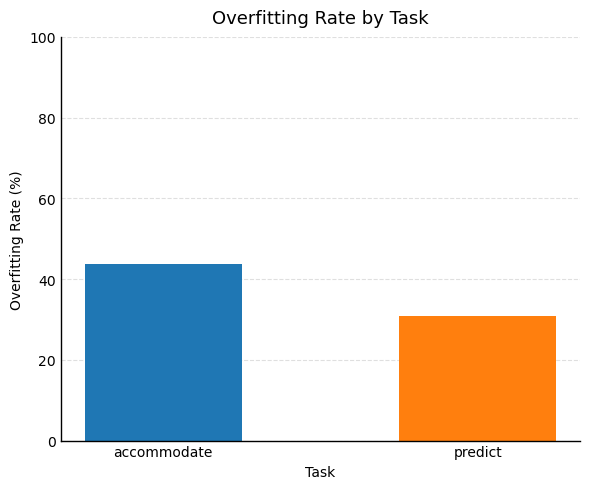

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Overall overfitting rate by task
overfit_summary = (
    df_params
    .groupby('task')['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100
overfit_summary['study'] = 'Study 3'
save_path = os.path.join(outputdirCombined, "overfit_summary_study3.csv")
overfit_summary.to_csv(save_path, index=False)

print(overfit_summary)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(
    overfit_summary['task'],
    overfit_summary['overfit_percent'],
    color=colors,
    width=0.5   # thinner bars (default is ~0.8)
)

# --- Clean look ---
# Remove top/right spines (box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: lighten left/bottom spines
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Labels
ax.set_title('Overfitting Rate by Task', fontsize=13, pad=10)
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)

# Optional: remove tick marks for cleaner look
ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.show()

Part 2: Testing distribution of all model parameter scores by task

model_param_score         task irrelevant_dim     0     1     2
0                  accommodate          color  13.0  50.0  44.0
1                  accommodate           feet  10.0  49.0  51.0
2                      predict          color  24.0  53.0  30.0
3                      predict           feet  17.0  56.0  37.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/3367612162.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/3367612162.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


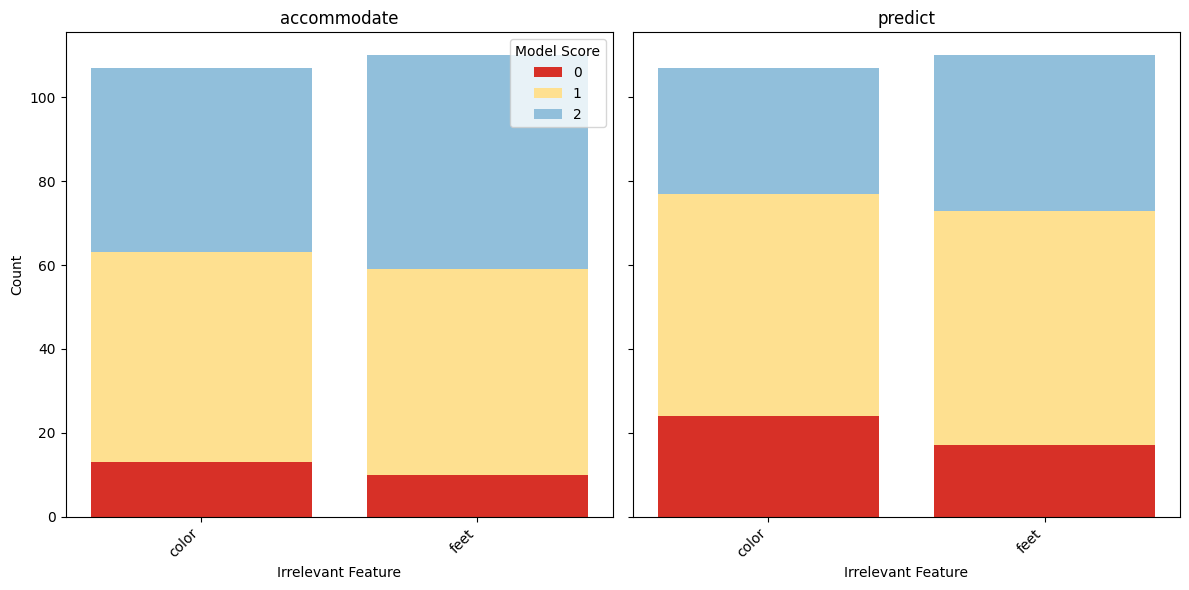

In [482]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

model_param_score   0    1   2
task                          
accommodate        23   99  95
predict            41  109  67
Chi-square = 10.383
df = 2
p-value = 0.0056


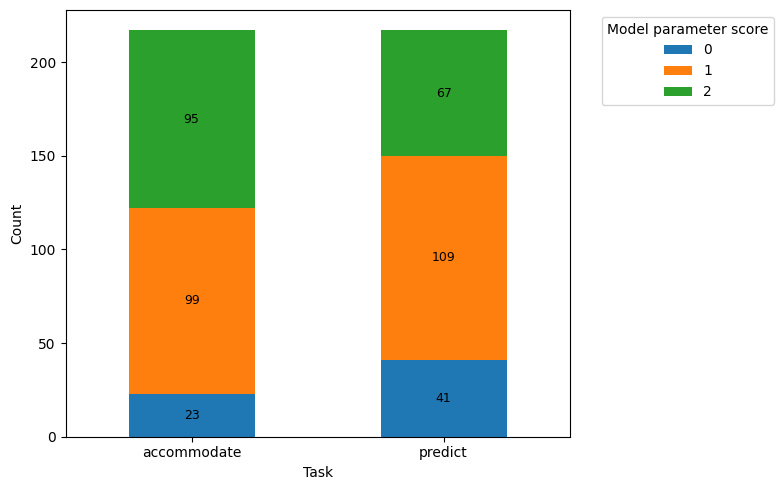

In [483]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
plt.show()
plt.close()

#Function of condition, wing relevance, and wing direction - the full distribution across that 
#code explanations later


**Primary Analysis #2: Predicting Feature Importance Ratings**

In [484]:
#Create map from short codes to feature descriptions

feet_map = {
    'round': 'f',
    'curly/pointy': 'c'
}

color_map = {
    'red': 'y',
    'green': 'g'
}



feature_maps = {
    'feet': feet_map,
    'color': color_map
}


In [485]:
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'color']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
df_filtered = compute_feature_importance_from_df(df_filtered)
if debug:
    print(df_combined['feet_importance'])

response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curl

In [486]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_combined[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

print(df_long.tail(20))

     participant     task relevant_dim irrelevant_dim color_high feet_high  \
848          415  predict        color           feet          Y         F   
849          416  predict         feet          color          Y         C   
850          417  predict         feet          color          Y         C   
851          418  predict         feet          color          G         F   
852          419  predict        color           feet          G         F   
853          420  predict         feet          color          Y         C   
854          421  predict        color           feet          Y         F   
855          422  predict         feet          color          Y         F   
856          423  predict        color           feet          G         C   
857          424  predict         feet          color          Y         C   
858          425  predict        color           feet          G         C   
859          426  predict         feet          color          Y

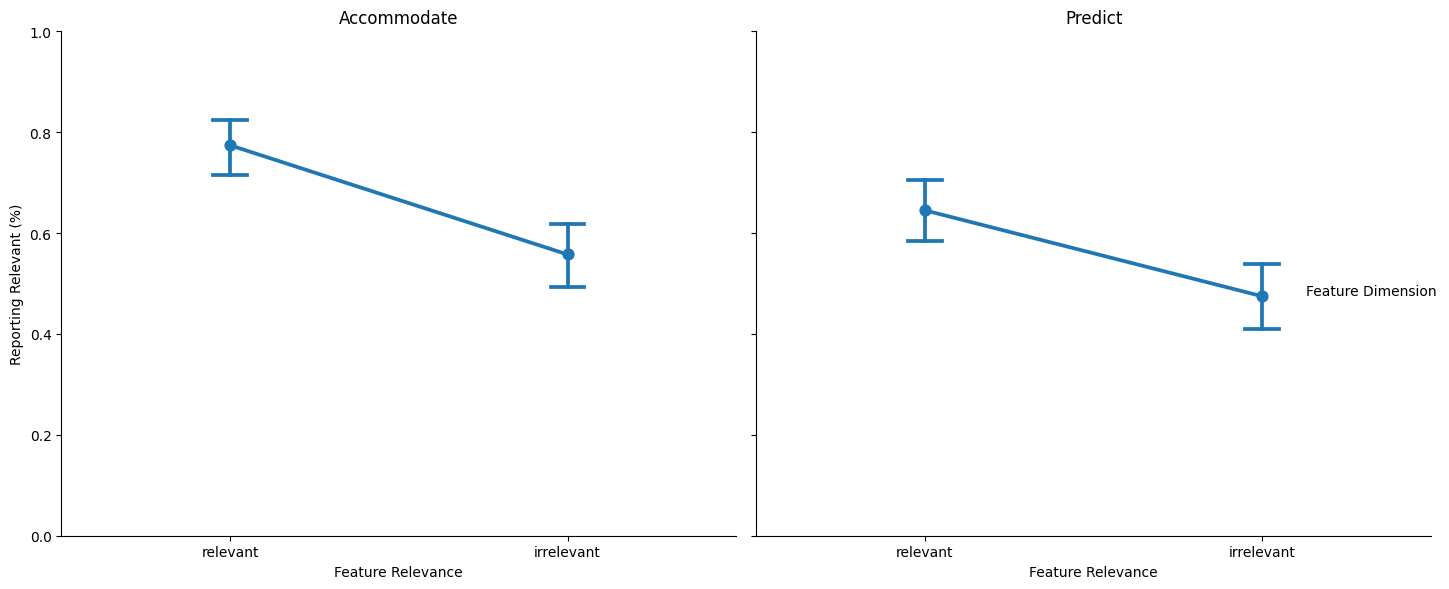

In [487]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

df_long['reported_relevant'] = (df_long['feature_importance'] != 0).astype(int)

g = sns.catplot(
    data=df_long,
    x="feature_relevance",
    y="reported_relevant",
    #hue="feature_dimension",
    col="task",
    kind="point",
    dodge=True,
    capsize=0.1,
    markers="o",
    height=6,
    aspect=1.2
)

# y-axis is proportion
g.set(ylim=(0, 1))

g.set_axis_labels("Feature Relevance", "Reporting Relevant (%)")

# nicer subplot titles
for ax in g.axes.flatten():
    ax.set_title(ax.get_title().split(' = ')[-1].capitalize())

g._legend.set_title("Feature Dimension")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure_RelevanceReportingByRelevantFeature.png'))
plt.show()

In [488]:
pd.crosstab(df_long['feature_relevance'], df_long['reported_relevant'])

reported_relevant,0,1
feature_relevance,,
irrelevant,210,224
relevant,126,308


In [489]:
import statsmodels.formula.api as smf

model = smf.logit(
    "reported_relevant ~ task * feature_relevance",
    data=df_long
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.640727
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      reported_relevant   No. Observations:                  868
Model:                          Logit   Df Residuals:                      864
Method:                           MLE   Df Model:                            3
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.04001
Time:                        11:08:25   Log-Likelihood:                -556.15
converged:                       True   LL-Null:                       -579.33
Covariance Type:            nonrobust   LLR p-value:                 4.756e-10
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

FEET — relevant: 214 points
FEET — irrelevant: 220 points
COLOR — relevant: 220 points
COLOR — irrelevant: 214 points


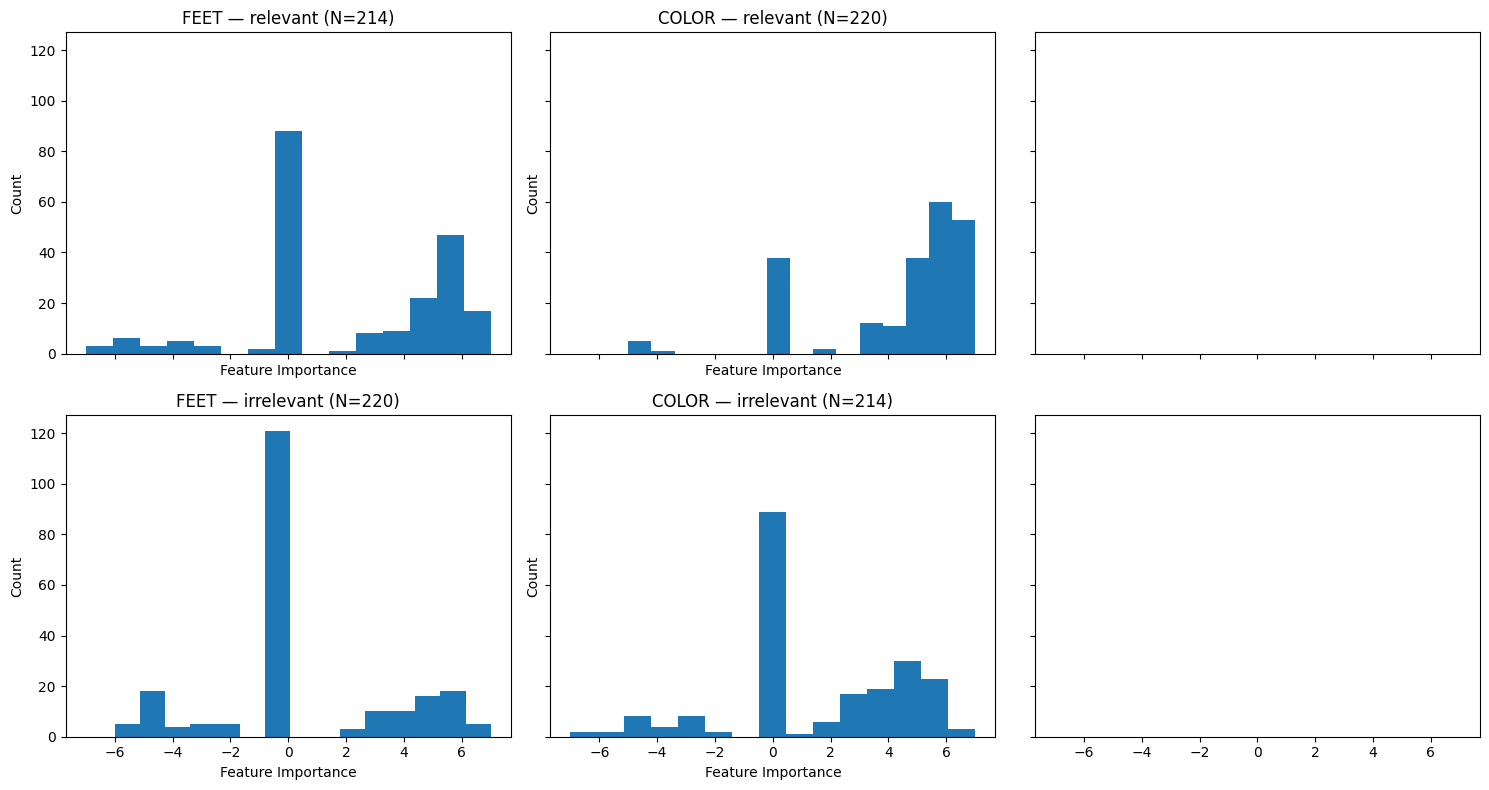

In [490]:
import matplotlib.pyplot as plt

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):
        
        ax = axes[row, col]
        
        subset = df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ]
        
        # Number of rows in this subset
        n_points = len(subset)
        print(f"{feat.upper()} — {rel}: {n_points} points")
        
        ax.hist(subset['feature_importance'], bins=15, density=False)
        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeature.png'))
plt.show()


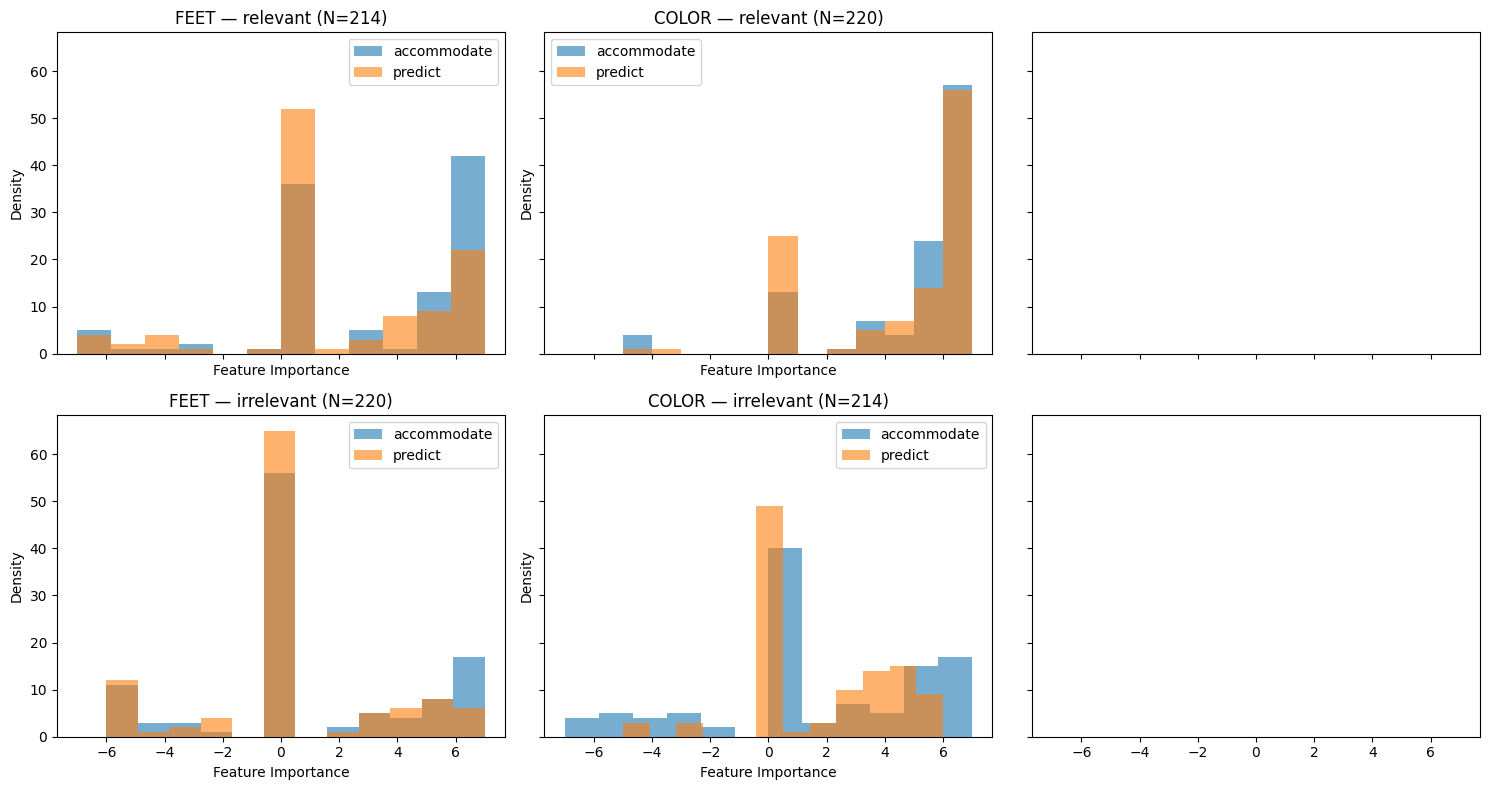

In [491]:
import matplotlib.pyplot as plt

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

In [492]:
print(df_long.head(220))

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              4  accommodate         feet          color          Y   
4              5  accommodate         feet          color          Y   
..           ...          ...          ...            ...        ...   
215          216  accommodate        color           feet          Y   
216          217  accommodate        color           feet          Y   
217          218      predict         feet          color          G   
218          219      predict        color           feet          G   
219          220      predict         feet          color          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

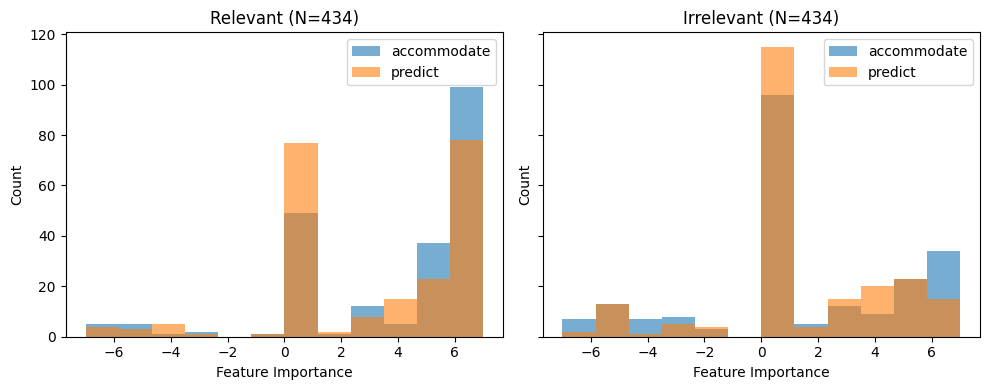

In [494]:
import matplotlib.pyplot as plt
import numpy as np
import os

relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# Common bins
bin_edges = np.linspace(
    df_long['feature_importance'].min(),
    df_long['feature_importance'].max(),
    13  # 12 bins = 13 edges
)

for i, rel in enumerate(relevance_states):
    ax = axes[i]

    for task in tasks:
        subset = df_long[
            (df_long['feature_relevance'] == rel) &
            (df_long['task'] == task)
        ]

        ax.hist(
            subset['feature_importance'],
            bins=bin_edges,
            alpha=0.6,
            label=task
        )

    n_points = len(df_long[df_long['feature_relevance'] == rel])

    ax.set_title(f"{rel.capitalize()} (N={n_points})")
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportance_byRelevance.png'))
plt.show()

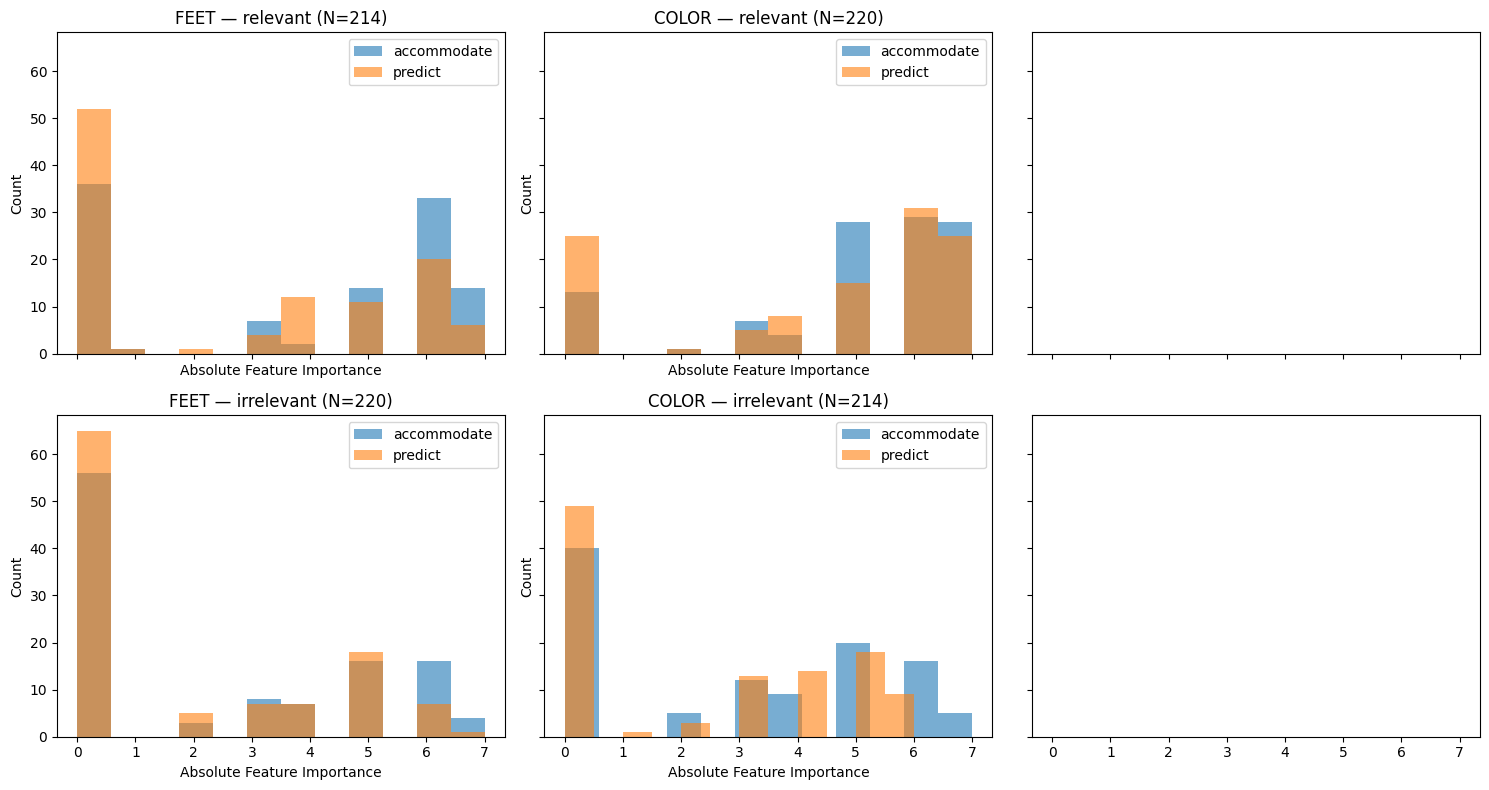

In [495]:
df_long['abs_feature_importance'] = df_long['feature_importance'].abs()
import matplotlib.pyplot as plt
import os

features = ['feet', 'color']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['abs_feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Absolute Feature Importance")
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'AbsoluteFeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

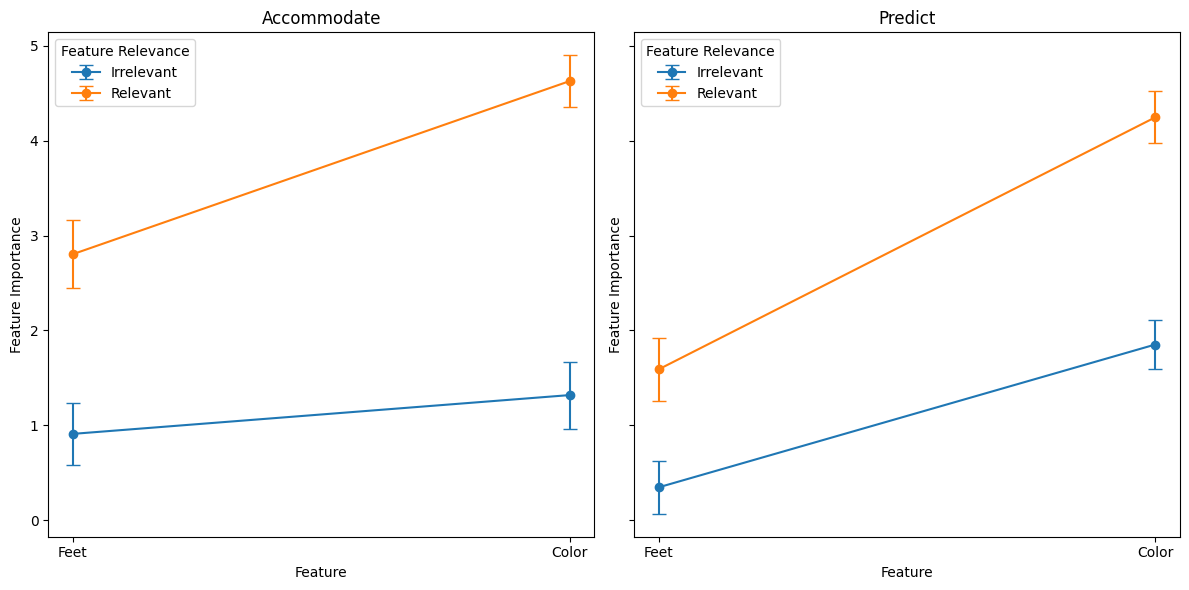

In [496]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'color']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure5FeatureImportanceByTaskAndRelevance.png'))
plt.show()

In [497]:
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           868             Method:                     REML              
No. Groups:                 434             Scale:                      11.1189           
Min. group size:            2               Log-Likelihood:             -2277.2583        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.728    0.226 16.470 0.000  3.284  4.172
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [498]:
print(df_long)
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_for_R-Study3.csv'), index=False)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              4  accommodate         feet          color          Y   
4              5  accommodate         feet          color          Y   
..           ...          ...          ...            ...        ...   
863          430      predict        color           feet          Y   
864          431      predict         feet          color          Y   
865          432      predict         feet          color          Y   
866          433      predict        color           feet          Y   
867          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [499]:
means = (
    df_long
    .groupby(["task", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance      mean       std  count
0  accommodate          relevant  3.728111  3.436567    217
1  accommodate        irrelevant  1.110599  3.531174    217
2      predict          relevant  2.935484  3.432616    217
3      predict        irrelevant  1.087558  2.900620    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/1213789995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["feature_importance"]


In [500]:
means = (
    df_long
    .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance feature_dimension      mean       std  count
0  accommodate          relevant             color  4.627273  2.860227    110
1  accommodate          relevant              feet  2.803738  3.735195    107
2  accommodate        irrelevant             color  1.317757  3.643547    107
3  accommodate        irrelevant              feet  0.909091  3.422927    110
4      predict          relevant             color  4.245455  2.889990    110
5      predict          relevant              feet  1.588785  3.436632    107
6      predict        irrelevant             color  1.850467  2.680481    107
7      predict        irrelevant              feet  0.345455  2.925485    110


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/3454135323.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]


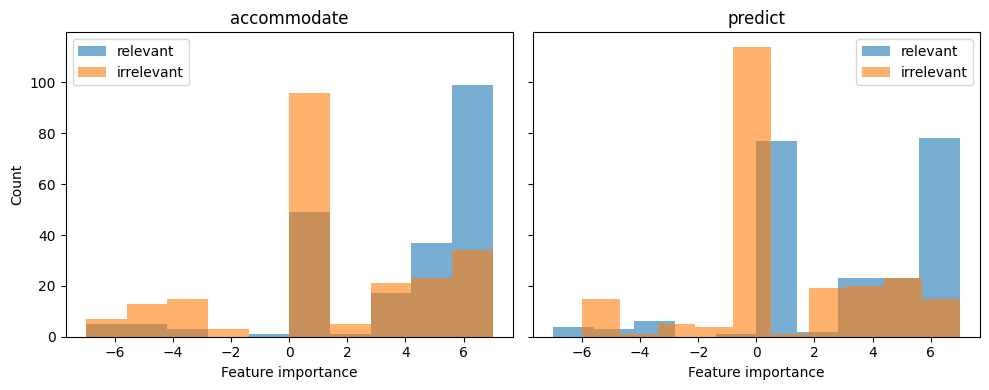

In [501]:
tasks = df_long['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_long.loc[
            (df_long['task'] == task) &
            (df_long['feature_relevance'] == label),
            'feature_importance'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("Feature importance")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3_FeatureImportanceByTaskAndRelevance.png'), dpi=300)
plt.show()


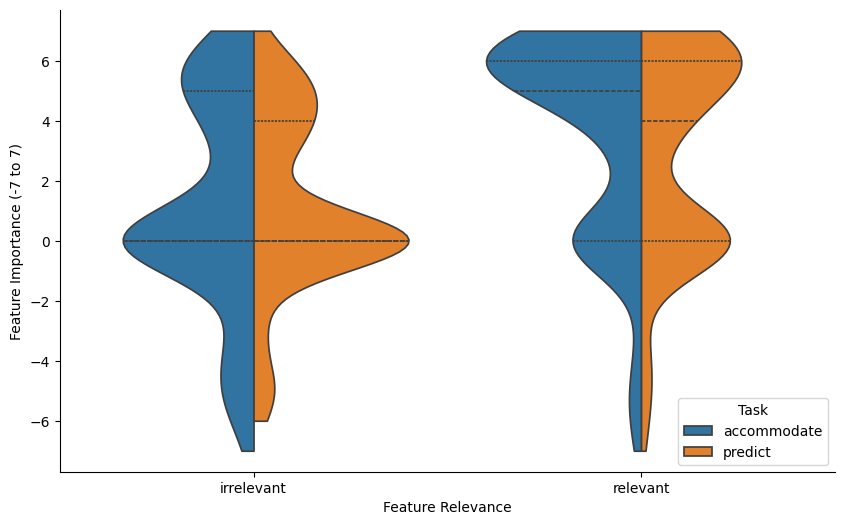

In [502]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


In [503]:
df_long['task'] = df_long['task'].astype('category')  # predict/accomodate
df_long['feature_dimension'] = df_long['feature_dimension'].astype('category')
df_long['feature_relevance'] = df_long['feature_relevance'].astype('category')


In [504]:
import statsmodels.formula.api as smf

# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         feature_importance
No. Observations:         868             Method:                     REML              
No. Groups:               434             Scale:                      7.9917            
Min. group size:          2               Log-Likelihood:             -2276.4388        
Max. group size:          2               Converged:                  Yes               
Mean group size:          2.0                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      1.111    0.219  5.063 0.000  0.681  1.541
task[T.predict]                               -

In [505]:
#Analyse the absolute value of feature importance ratings (ignoring direction)
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()
avg_importance_task = (
    df_longAbs
        .groupby(['task', 'feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_task)
avg_importance_relevance = (
    df_longAbs
        .groupby(['feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)

print(avg_importance_relevance)

avg_importance_feature = (
    df_longAbs
        .groupby(['feature_dimension'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_feature)

          task feature_relevance  abs_feature_importance
0  accommodate        irrelevant                2.649770
1  accommodate          relevant                4.354839
2      predict        irrelevant                2.046083
3      predict          relevant                3.525346
  feature_relevance  abs_feature_importance
0        irrelevant                2.347926
1          relevant                3.940092
  feature_dimension  abs_feature_importance
0             color                3.670507
1              feet                2.617512


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/1409563864.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'feature_relevance'])['abs_feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/1409563864.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['feature_relevance'])['abs_feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/1409563864.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

In [506]:
df_irrel = df_longAbs[df_longAbs["feature_relevance"] == "irrelevant"].copy()

accom_vals = df_irrel[df_irrel["task"]=="accommodate"]["abs_feature_importance"]
predict_vals = df_irrel[df_irrel["task"]=="predict"]["abs_feature_importance"]
mean_accom = np.mean(accom_vals)
mean_predict = np.mean(predict_vals)

print(f"Mean (accommodate) = {mean_accom:.3f}")
print(f"Mean (predict) = {mean_predict:.3f}")
t, p = ttest_ind(predict_vals, accom_vals, equal_var=False)  # Welch's t-test
print(f"t = {t:.3f}, p = {p:.4f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_feature_importance": [mean_accom, mean_predict],
    "t_stat": [t, t], 
    "p_value": [p, p]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_abs_featureimportance.csv"))

Mean (accommodate) = 2.650
Mean (predict) = 2.046
t = -2.562, p = 0.0108


**Analysis 3: Predicting Fertility Ratings**

In [39]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))


           task  conditionOrder item fertility_score
0   accommodate               1  G_C            6.75
1   accommodate               1  G_F             2.5
2   accommodate               1  Y_C            7.75
3   accommodate               1  Y_F             2.5
4   accommodate               2  G_C            6.75
5   accommodate               2  G_F             7.5
6   accommodate               2  Y_C             3.0
7   accommodate               2  Y_F             3.5
8   accommodate               3  G_C            2.25
9   accommodate               3  G_F             8.0
10  accommodate               3  Y_C             3.5
11  accommodate               3  Y_F            5.75
12  accommodate               4  G_C            3.75
13  accommodate               4  G_F             5.5
14  accommodate               4  Y_C             7.0
15  accommodate               4  Y_F            7.75
16  accommodate               5  G_C            8.25
17  accommodate               5  G_F          

In [40]:
#Get food consumption ratings by item

df = df_combined[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate             183  Y_C               8.0         feet   
0    accommodate             183  G_F               8.0         feet   
0    accommodate             183  Y_F               5.0         feet   
0    accommodate             183  G_C               3.0         feet   
1    accommodate              75  Y_C               5.0         feet   
..           ...             ...  ...               ...          ...   
432      predict             204  G_F               2.0        color   
433      predict             120  G_F               4.0        color   
433      predict             120  G_C               2.0        color   
433      predict             120  Y_C               7.0        color   
433      predict             120  Y_F               8.0        color   

    irrelevant_dim color_high feet_high  
0            color          Y         F  
0            color          Y         F  
0        

In [41]:
#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

             task  conditionOrder item testing_responses relevant_dim  \
0     accommodate             183  Y_C               8.0         feet   
1     accommodate             183  G_F               8.0         feet   
2     accommodate             183  Y_F               5.0         feet   
3     accommodate             183  G_C               3.0         feet   
4     accommodate              75  Y_C               5.0         feet   
...           ...             ...  ...               ...          ...   
1731      predict             204  G_F               2.0        color   
1732      predict             120  G_F               4.0        color   
1733      predict             120  G_C               2.0        color   
1734      predict             120  Y_C               7.0        color   
1735      predict             120  Y_F               8.0        color   

     irrelevant_dim color_high feet_high fertility_score error abs_error  \
0             color          Y         F       

In [42]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)
print("Mean error by color:")
print(df_merged.groupby('color')['error'].mean())

print("Mean error by feet:")
print(df_merged.groupby('feet')['error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['feet'] == 'C', 'error']
color2 = df_merged.loc[df_merged['feet'] == 'F', 'error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean error by color:
color
G    0.153226
Y    0.235599
Name: error, dtype: object
Mean error by feet:
feet
C    0.374424
F    0.014401
Name: error, dtype: object
T = 3.623, p = 0.000


C
F


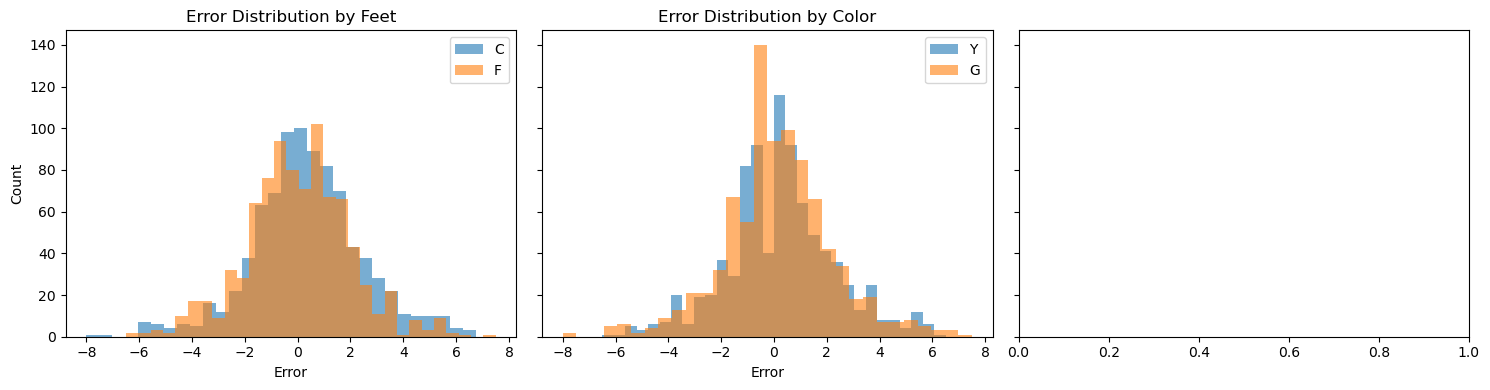

In [32]:
import matplotlib.pyplot as plt

# Make sure error is numeric
df_merged['error'] = pd.to_numeric(df_merged['error'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Tail
for t in df_merged['feet'].unique():
    print(t)
    axes[0].hist(
        df_merged.loc[df_merged['feet'] == t, 'error'],
        bins=30,
        alpha=0.6,
        label=t
    )
axes[0].set_title('Error Distribution by Feet')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Color ---
for c in df_merged['color'].unique():
    axes[1].hist(
        df_merged.loc[df_merged['color'] == c, 'error'],
        bins=30,
        alpha=0.6,
        label=c
    )
axes[1].set_title('Error Distribution by Color')
axes[1].set_xlabel('Error')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7_ErrorDistributionByFeature.png'), dpi=300)
plt.show()


In [361]:
print(df_merged)

             task  conditionOrder item testing_responses relevant_dim  \
0     accommodate             183  Y_C               8.0         feet   
1     accommodate             183  G_F               8.0         feet   
2     accommodate             183  Y_F               5.0         feet   
3     accommodate             183  G_C               3.0         feet   
4     accommodate              75  Y_C               5.0         feet   
...           ...             ...  ...               ...          ...   
1731      predict             204  G_F               2.0        color   
1732      predict             120  G_F               4.0        color   
1733      predict             120  G_C               2.0        color   
1734      predict             120  Y_C               7.0        color   
1735      predict             120  Y_F               8.0        color   

     irrelevant_dim color_high feet_high fertility_score  error abs_error  \
0             color          Y         F      

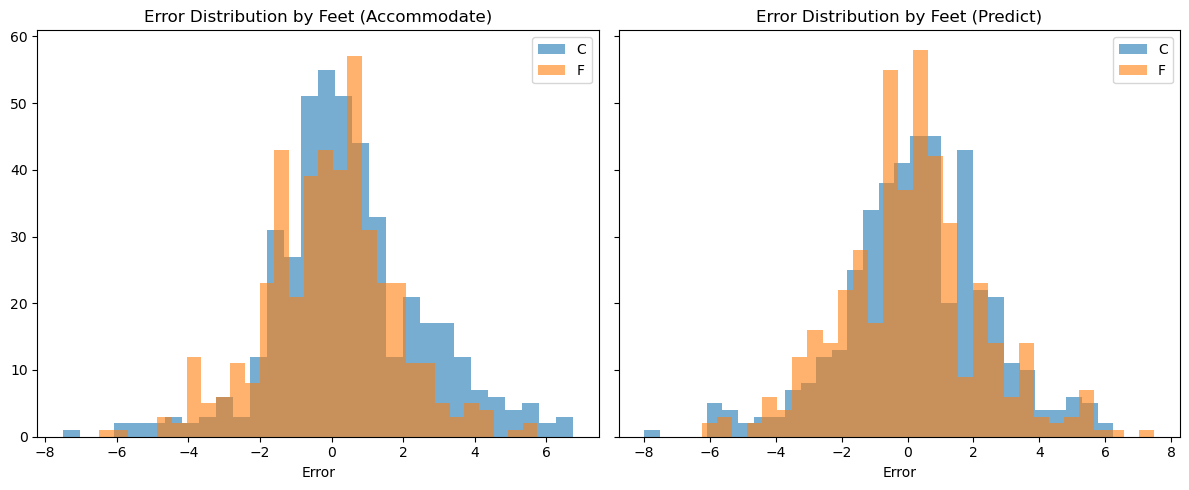

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(['accommodate', 'predict']):
    for w in df_merged['feet'].unique():
        axes[i].hist(
            df_merged.loc[(df_merged['feet'] == w) & (df_merged['task'] == task), 'error'],
            bins=30,
            alpha=0.6,
            label=w
        )
    axes[i].set_title(f'Error Distribution by Feet ({task.capitalize()})')
    axes[i].set_xlabel('Error')
    axes[i].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7b_ErrorDistributionByFeetAndTask.png'), dpi=300)
plt.show()

In [ ]:
#df filtered same as above
#Group by average food amount per item in training
df = df_filtered[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2filtered = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2filtered
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))

#Get food consumption ratings by item

df = df_filtered[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)


In [34]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print("Mean abs_error by color:")
print(df_merged.groupby('color')['abs_error'].mean())

print("Mean abs_error by feet:")
print(df_merged.groupby('feet')['abs_error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['feet'] == 'C', 'abs_error']
color2 = df_merged.loc[df_merged['feet'] == 'F', 'abs_error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean abs_error by color:
color
G    1.584677
Y    1.559332
Name: abs_error, dtype: object
Mean abs_error by feet:
feet
C    1.639977
F    1.504032
Name: abs_error, dtype: object
T = 2.067, p = 0.039


In [43]:
#t-test: predict vs accomodate absolute error
df_merged['error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.488191
predict        1.655818
Name: error, dtype: float64
T = -2.551, p = 0.011


In [37]:
#t-test: predict vs accomodate absolute error
df_merged['abs_error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['abs_error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'abs_error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'abs_error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.191761
predict        1.323106
Name: abs_error, dtype: float64
T = -2.320, p = 0.020


Part 2: Correlations

In [463]:
# df_params
df_params['id'] = list(zip(df_params['task'], df_params['conditionOrder']))

# df_corr already has this
df_corr['id'] = df_corr['participant']

# Now merge cleanly
df_merged_test = df_params.merge(df_corr, on='id', how='inner')

In [366]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['color_match_high']  = (df_merged['color']  == df_merged['color_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['color','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



        participant     task feature_dimension high_value feature_relevance  \
828  (predict, 201)  predict             color          Y        irrelevant   
829  (predict, 201)  predict              feet          C          relevant   
830  (predict, 202)  predict             color          G          relevant   
831  (predict, 202)  predict              feet          C        irrelevant   
832  (predict, 203)  predict             color          G        irrelevant   
833  (predict, 203)  predict              feet          F          relevant   
834  (predict, 204)  predict             color          Y          relevant   
835  (predict, 204)  predict              feet          C        irrelevant   
836  (predict, 205)  predict             color          G        irrelevant   
837  (predict, 205)  predict              feet          C          relevant   
838  (predict, 206)  predict             color          G          relevant   
839  (predict, 206)  predict              feet      

In [452]:
df_corr.to_csv(os.path.join(outputdirCleaned, 'df_corr_for_R.csv'), index=False)

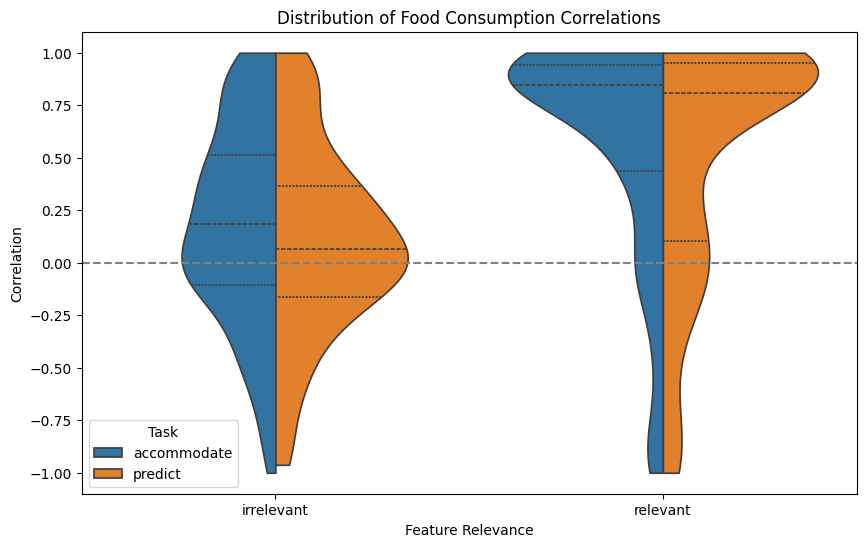

In [367]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


In [369]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr,
    groups=df_corr["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(
    os.path.join(outputdir, "Figure11_mixedlm_correlationStats.csv")
)

                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.2610     
Min. group size:             2                 Log-Likelihood:               -656.4278  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.035  5.105 0.000  0.109  0.245
task[T.predict]                               -

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [370]:
avg_corr_task_rel = df_corr.groupby(
    ['task'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)
avg_corr_feature = df_corr.groupby(
    ['feature_dimension'],
    as_index=False
)['correlation'].mean()

print(avg_corr_feature)
avg_corr_relevance = df_corr.groupby(
    ['feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_relevance)

          task  correlation
0  accommodate     0.377317
1      predict     0.309035
  feature_dimension  correlation
0             color     0.454873
1              feet     0.231479
  feature_relevance  correlation
0        irrelevant     0.142213
1          relevant     0.544139


In [454]:
print(df_corr.tail(20))

        participant     task feature_dimension high_value feature_relevance  \
848  (predict, 211)  predict             color          G        irrelevant   
849  (predict, 211)  predict              feet          F          relevant   
850  (predict, 212)  predict             color          Y          relevant   
851  (predict, 212)  predict              feet          F        irrelevant   
852  (predict, 213)  predict             color          G        irrelevant   
853  (predict, 213)  predict              feet          C          relevant   
854  (predict, 214)  predict             color          G          relevant   
855  (predict, 214)  predict              feet          F        irrelevant   
856  (predict, 215)  predict             color          G        irrelevant   
857  (predict, 215)  predict              feet          F          relevant   
858  (predict, 216)  predict             color          Y          relevant   
859  (predict, 216)  predict              feet      

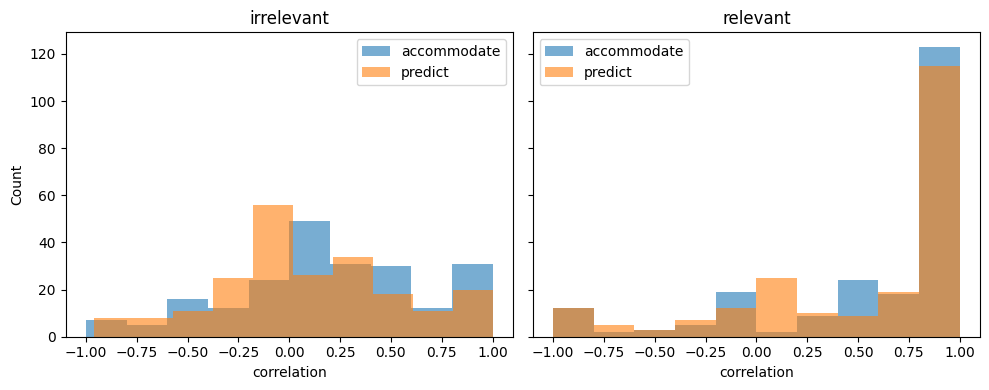

In [372]:
relevance_states = df_corr['feature_relevance'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(relevance_states),
    figsize=(5 * len(relevance_states), 4),
    sharey=True
)

if len(relevance_states) == 1:
    axes = [axes]

for ax, rel in zip(axes, relevance_states):
    for task in df_corr['task'].unique():
        values = df_corr.loc[
            (df_corr['feature_relevance'] == rel) &
            (df_corr['task'] == task),
            'correlation'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=task)

    ax.set_title(rel)
    ax.set_xlabel("correlation")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9_FeatureCorrelationByRelevanceAndTask.png'), dpi=300)
plt.show()

In [373]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  correlation
0  accommodate        irrelevant     0.177037
1  accommodate          relevant     0.577597
2      predict        irrelevant     0.107389
3      predict          relevant     0.510681


In [375]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['abs_correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  abs_correlation
0  accommodate        irrelevant         0.402126
1  accommodate          relevant         0.727489
2      predict        irrelevant         0.347978
3      predict          relevant         0.693590


In [381]:
import statsmodels.formula.api as smf

model = smf.ols(
    "abs_correlation ~ task * feature_relevance",
    df_corr
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        abs_correlation   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     86.09
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.63e-49
Time:                        13:20:09   Log-Likelihood:                -213.85
No. Observations:                 868   AIC:                             435.7
Df Residuals:                     864   BIC:                             454.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [384]:
nan_corrs = df_corr[pd.isna(df_corr['correlation'])]
#print(nan_corrs)
df_corr_clean = df_corr[pd.notna(df_corr['correlation'])].copy()



In [385]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr_clean,
    groups=df_corr_clean["participant"],  # random intercept per participant
    re_formula="~feature_relevance"  # random slopes if it converges
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_correlation.csv"))


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.1909     
Min. group size:             2                 Log-Likelihood:               -646.7096  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.031  5.658 0.000  0.116  0.238
task[T.predict]                               -

Supplementary: Irrelevant Feature Association with food amount and food consumption ratings

Supplementary Models Looking at Feature Dimension

In [412]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_filtered.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    111     93
predict        140     64
Chi-square = 8.117
df = 1
p-value = 0.0044


model_param_score         task irrelevant_dim     0     1     2
0                  accommodate          color  11.0  41.0  43.0
1                  accommodate           feet  10.0  49.0  50.0
2                      predict          color  21.0  49.0  27.0
3                      predict           feet  14.0  56.0  37.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


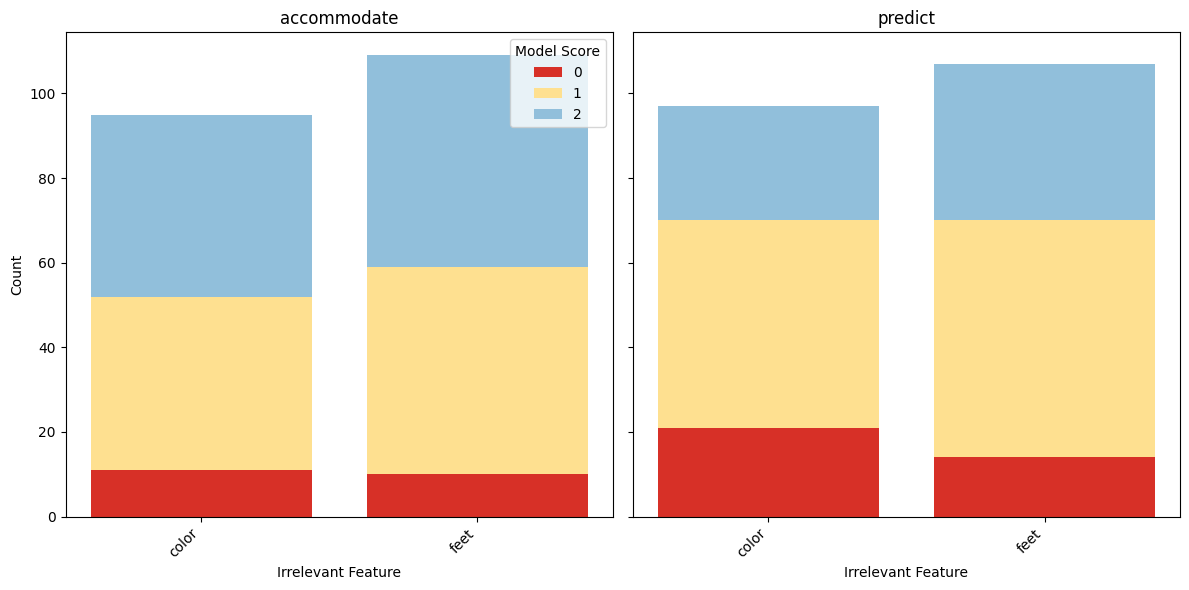

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

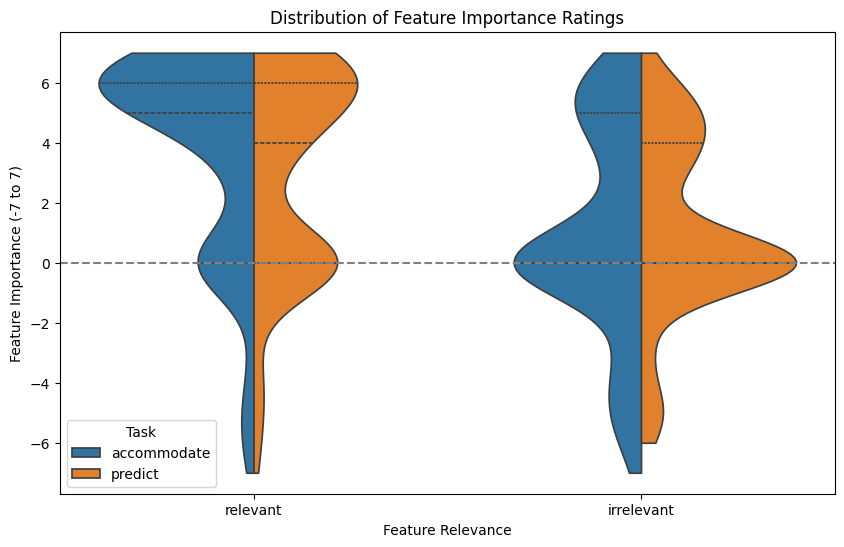

                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           816             Method:                     REML              
No. Groups:                 408             Scale:                      11.0243           
Min. group size:            2               Log-Likelihood:             -2137.2539        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.897    0.232 16.764 0.000  3.441  4.353
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [416]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_filtered[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
#model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


In [409]:
print(df_long)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              5  accommodate         feet          color          Y   
4              6  accommodate        color           feet          Y   
..           ...          ...          ...            ...        ...   
811          430      predict        color           feet          Y   
812          431      predict         feet          color          Y   
813          432      predict         feet          color          Y   
814          433      predict        color           feet          Y   
815          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [417]:
df_long.to_csv(os.path.join(outputdirCleaned, 'df_long_for_R-Study3Filtered.csv'), index=False)

In [ ]:
import ast
import matplotlib.pyplot as plt
#Calculate reported food amounts during testing
def AverageFoodCalclator(participants_to_use):
    df_subset = df_combined[df_combined['participant'].isin(participants_to_use)]
    all_trials = []
    for i in df_subset['participant']:
        ratings     = df_subset[df_subset['participant'] == i]['testing_responses'].iloc[0]
        categories = df_subset[df_subset['participant'] == i]['testing_categories'].iloc[0]
        task = df_subset[df_subset['participant'] == i]['task'].iloc[0]
        row = df_subset[df_subset['participant'] == i].iloc[0]
        tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
        shape_yes = 1 if row['shape_discrete_slider.response'] == 'Yes' else 0
        color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
        num_features_relevant = tail_yes + shape_yes + color_yes
        df_participant = pd.DataFrame(list(zip(
            [i]*len(ratings),  # Repeat participant ID and task to match the number of ratings
            ratings,
            [task]*len(ratings), # Repeat participant ID and task to match the number of ratings
            categories,
            [num_features_relevant]*len(ratings)
        )), columns=['participant', 'ratings', 'task', 'category', 'num_features_relevant'])
        all_trials.append(df_participant)
    df_average = pd.concat(all_trials, ignore_index=True)
    avg_ratings_cond = df_average.groupby(['task', 'category'])['ratings'].mean()
    return df_average, avg_ratings_cond

participants_to_use = df_combined['participant'].tolist()
df_average, avg_rating_cond = AverageFoodCalclator(participants_to_use)
print(avg_rating_cond)
print(df_average)
# Group by task, category, and num_features_relevant
model_parameter_score = df_average.groupby(
    ['num_features_relevant']
)['ratings'].mean().reset_index()

print(model_parameter_score)
# Group by task, category, and num_features_relevant
avg_ratings_cond_by_relevance = df_average.groupby(
    ['task', 'category', 'num_features_relevant']
)['ratings'].mean().reset_index()


print(avg_ratings_cond_by_relevance)
category_order = ['low', 'medium', 'high']
avg_ratings_cond_by_relevance['category'] = pd.Categorical(
    avg_ratings_cond_by_relevance['category'],
    categories=category_order,
    ordered=True
)
import seaborn as sns
sns.catplot(
    data=avg_ratings_cond_by_relevance,
    x='category', y='ratings',
    hue='num_features_relevant', col='task',
    kind='bar', palette='Set2'
)
plt.show()

<Axes: xlabel='category', ylabel='ratings'>

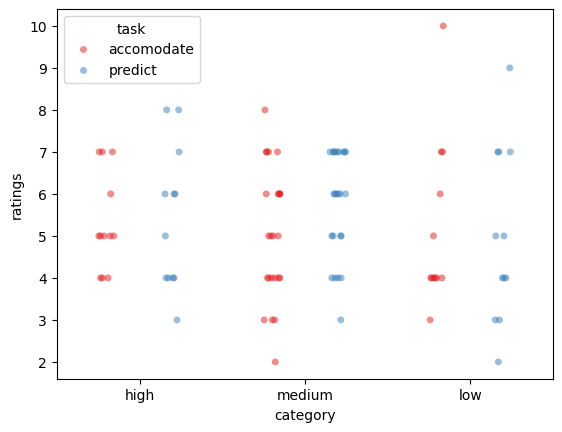

In [ ]:
sns.stripplot(data=df_average, x='category', y='ratings', hue='task', 
              palette='Set1', dodge=True, jitter=True, color='black', alpha=0.5)

In [ ]:
print(df_average.head(20))

    participant  ratings        task category  num_features_relevant
0             1      6.0  accomodate     high                      1
1             1      5.0  accomodate   medium                      1
2             1      3.0  accomodate      low                      1
3             1      5.0  accomodate   medium                      1
4             1      5.0  accomodate   medium                      1
5             1      7.0  accomodate     high                      1
6             1      4.0  accomodate      low                      1
7             1      4.0  accomodate   medium                      1
8             2      5.0  accomodate   medium                      2
9             2      3.0  accomodate   medium                      2
10            2      5.0  accomodate     high                      2
11            2      7.0  accomodate      low                      2
12            2      7.0  accomodate     high                      2
13            2      5.0  accomoda

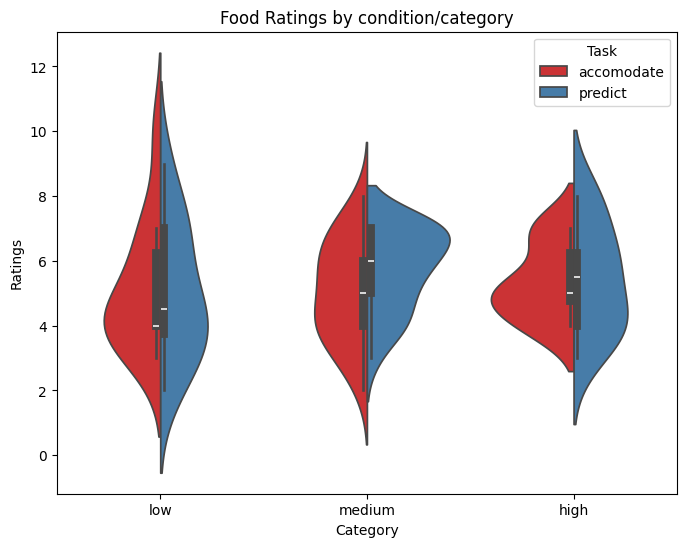

In [ ]:
order = ['low', 'medium', 'high']
# Violin plot: ratings by category, separated by task
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_average,
    x='category',       # x-axis: categories
    y='ratings',        # y-axis: ratings
    hue='task',         # split by task
    split=True,         # split the violins by task
    palette='Set1',
    inner='box',    # show box plot of data inside
    order = order
)

plt.ylabel('Ratings')
plt.xlabel('Category')
plt.title('Food Ratings by condition/category')
plt.legend(title='Task')
#plt.savefig(f'{study}Plots/ViolinRatings.png', bbox_inches='tight')
plt.show()

In [ ]:
def decode_rel(rel_values):
    """
    rel_values: Series of lists of rel codes
    """

    flat_vals = []
    for v in rel_values:
        if isinstance(v, list):
            flat_vals.extend(v)

    flat_vals = pd.Series(flat_vals).dropna().unique()

    if len(flat_vals) == 0:
        return pd.Series({'feature_relevance': np.nan})

    # irrelevant: only I-codes
    if all(v.startswith('I') for v in flat_vals):
        return pd.Series({'feature_relevance': 'irrelevant'})

    # relevant: contains R or L
    if any(v.startswith(('R', 'L')) for v in flat_vals):
        return pd.Series({'feature_relevance': 'relevant'})

    raise ValueError(f"Unexpected rel codes: {flat_vals}")


feature_relevance_rows = []

for (cond, task), subdf in df_combined.groupby(['conditionOrder', 'task']):
    for feat in ['tail', 'color', 'shape']:
        relevance = decode_rel(subdf[f'training_{feat}'])

        feature_relevance_rows.append({
            'conditionOrder': cond,
            'task': task,
            'feature_dimension': feat,
            'feature_relevance': relevance
        })

df_feature_relevance = pd.DataFrame(feature_relevance_rows)
print(df_feature_relevance)

    conditionOrder        task feature_dimension  \
0                1  accomodate              tail   
1                1  accomodate             color   
2                1  accomodate             shape   
3                1     predict              tail   
4                1     predict             color   
5                1     predict             shape   
6                2  accomodate              tail   
7                2  accomodate             color   
8                2  accomodate             shape   
9                2     predict              tail   
10               2     predict             color   
11               2     predict             shape   
12               3  accomodate              tail   
13               3  accomodate             color   
14               3  accomodate             shape   
15               3     predict              tail   
16               3     predict             color   
17               3     predict             shape   
18          

In [ ]:
features = ['shape', 'color', 'tail']
long_rows = []

for _, row in df_combined.iterrows():
    for feat in features:
        long_rows.append({
            'participant': row['participant'],
            'conditionOrder': row['conditionOrder'],
            'task': row['task'],
            'feature_dimension': feat,

            'discrete': row[f'{feat}_discrete_slider.response'],
            'direction': row[f'{feat}_direction_slider.response'],
            'continuous': row[f'{feat}_continuous_slider.response'],
        })

df_long = pd.DataFrame(long_rows)
print(df_long.head(10))

   participant  conditionOrder        task feature_dimension discrete  \
0            1               4  accomodate             shape      Yes   
1            1               4  accomodate             color       No   
2            1               4  accomodate              tail       No   
3            2               1  accomodate             shape       No   
4            2               1  accomodate             color      Yes   
5            2               1  accomodate              tail      Yes   
6            3               3  accomodate             shape      Yes   
7            3               3  accomodate             color      Yes   
8            3               3  accomodate              tail      Yes   
9            4               2  accomodate             shape      Yes   

       direction  continuous  
0         Square         5.0  
1            NaN         NaN  
2            NaN         NaN  
3            NaN         NaN  
4           Blue         4.0  
5  Having 

In [ ]:
df_long = df_long.merge(
    df_feature_relevance,
    on=['conditionOrder', 'task', 'feature_dimension'],
    how='left'
)
print(df_long.head(21))

    participant  conditionOrder        task feature_dimension discrete  \
0             1               4  accomodate             shape      Yes   
1             1               4  accomodate             color       No   
2             1               4  accomodate              tail       No   
3             2               1  accomodate             shape       No   
4             2               1  accomodate             color      Yes   
5             2               1  accomodate              tail      Yes   
6             3               3  accomodate             shape      Yes   
7             3               3  accomodate             color      Yes   
8             3               3  accomodate              tail      Yes   
9             4               2  accomodate             shape      Yes   
10            4               2  accomodate             color      Yes   
11            4               2  accomodate              tail      Yes   
12            5               2     pr